# Public Infrastructure Data Processing and Modeling Pipeline

This notebook provides a clean, end-to-end workflow to preprocess a messy civil infrastructure dataset, visualize budgeting trends, and train a machine learning model to predict total project costs.

### Libraries Used:
* **`pandas`**: For data manipulation, handling missing records, and reading spreadsheets.
* **`numpy`**: For numerical operations and matrix combining.
* **`matplotlib.pyplot`**: For creating custom visual diagrams (bar, line, and pie charts).
* **`OneHotEncoder`** (`sklearn.preprocessing`): For converting text columns into computer-readable numbers.
* **`train_test_split`** (`sklearn.model_selection`): For splitting the data into training and testing datasets.
* **`RandomForestRegressor`** (`sklearn.ensemble`): Our primary machine learning model used to predict project costs.
* **`mean_absolute_error`**, **`mean_squared_error`**, **`r2_score`** (`sklearn.metrics`): For calculating our final accuracy errors (MAE, RMSE, $R^2$).

In [3]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries successfully imported!")

Libraries successfully imported!


## Step 1: Loading and Inspecting the Dataset

We read the raw CSV dataset into a Pandas DataFrame and display its basic shape and column names to confirm the data structure before processing.

In [4]:
# Load the messy dataset
df = pd.read_csv("C&W-MessyData.csv")

# Print structural dimensions
print("Dataset Shape (Rows, Columns):", df.shape)
print("\nDataset Columns:\n", df.columns.tolist())


# Preview the first few rows
df.head()

Dataset Shape (Rows, Columns): (90, 10)

Dataset Columns:
 ['Project_Name', 'District', 'Tehsil/Town', 'Year_Sanctioned', 'No._of_Floors', 'Building_Type', 'Structure_Type', 'Foundation_Type', 'Cost-per-Sqft', 'Total_Cost (in Millions)']


,Project_Name,District,Tehsil/Town,Year_Sanctioned,No._of_Floors,Building_Type,Structure_Type,Foundation_Type,Cost-per-Sqft,Total_Cost (in Millions)
0,GGPS Bagah Darra,Haripur,Khanpur (48),08/04/2016,1.0,Education,RCC,Raft,3800.0,16.43
1,GPS Ranja,Haripur,Ghazi (47),07/27/2020,2.0,Education,NaN,Raft,NaN,24.32
2,GPS Sarrara,Haripur,Haripur (46),08/06/2020,2.0,Education,RCC,Raft,3800.0,24.74
3,GGPS Koka,NaN,Haripur (46),11/09/2019,NaN,NaN,NaN,NaN,3800.0,NaN
4,GGMS Pind Hashim Khan,Haripur,Haripur (46),11/26/2019,2.0,NaN,RCC,NaN,NaN,34.25


## Step 2: Data Preprocessing & Categorical Standardization

Instead of manufacturing artificial dates or forcing a biased timeline trend onto our dataset, we preserve the missing chronological properties as true empty states (`NaN` or `NaT`). 

Our strategy ensures:
1. **Target Integrity Preservation**: Rows with missing `Total_Cost (in Millions)` target values are dropped (reducing the dataset from 90 to 72 active operational records) to avoid introducing synthetic target bias.
2. **Text Standardization & Mode Imputation**: Strips trailing text whitespace, converts empty string values to actual `NaN` objects, and imputes missing categorical entries using their respective column **modes**.
3. **Numerical Median Imputation**: Missing values in numerical attributes (`No._of_Floors` and `Cost-per-Sqft`) are filled using their column **medians** to protect against outlier distortion.
4. **No Timeline Imputation**: `Year_Sanctioned` is parsed into a datetime feature (`Cleaned_Date`), but missing entries are explicitly left as `NaT` (Not a Time) or `NaN` to preserve chronological accuracy.

In [5]:
import numpy as np
import pandas as pd

# 1. Load raw dataset (90 rows)
df = pd.read_csv("C&W-MessyData.csv")

# 2. DROP rows where target variable is missing (90 -> 72 rows)
df = df.dropna(subset=['Total_Cost (in Millions)']).copy()

# 3. Parse dates
df['Year_Sanctioned'] = pd.to_datetime(df['Year_Sanctioned'], errors='coerce', format='mixed', dayfirst=True)
df['Cleaned_Year'] = df['Year_Sanctioned'].dt.year

# 4. Clean & Impute Categorical Features with Mode
cat_cols = ['District', 'Tehsil/Town', 'Building_Type', 'Structure_Type', 'Foundation_Type']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().replace(['nan', 'NaN', ''], np.nan)
        df[col] = df[col].fillna(df[col].mode()[0])

# 5. Impute Numerical Features with Median
df['No._of_Floors'] = df['No._of_Floors'].fillna(df['No._of_Floors'].median())
df['Cost-per-Sqft'] = df['Cost-per-Sqft'].fillna(df['Cost-per-Sqft'].median())

print(f"Final Operational Shape: {df.shape}")  # (72, 11)
df

Final Operational Shape: (72, 11)


,Project_Name,District,Tehsil/Town,Year_Sanctioned,No._of_Floors,Building_Type,Structure_Type,Foundation_Type,Cost-per-Sqft,Total_Cost (in Millions),Cleaned_Year
0,GGPS Bagah Darra,Haripur,Khanpur (48),2016-04-08,1.0,Education,RCC,Raft,3800.0,16.43,2016
1,GPS Ranja,Haripur,Ghazi (47),2020-07-27,2.0,Education,RCC,Raft,3800.0,24.32,2020
2,GPS Sarrara,Haripur,Haripur (46),2020-06-08,2.0,Education,RCC,Raft,3800.0,24.74,2020
4,GGMS Pind Hashim Khan,Haripur,Haripur (46),2019-11-26,2.0,Education,RCC,Raft,3800.0,34.25,2019
5,GHS Kangra,Haripur,Khanpur (48),2018-02-15,2.0,Education,RCC,Raft,3800.0,19.48,2018
...,...,...,...,...,...,...,...,...,...,...,...
83,Sub-Divisional Complex Ghazi,Haripur,Ghazi (47),2024-11-06,2.0,Revenue,RCC,Raft,4500.0,59.20,2024
85,Police Post Kot Najibullah,Haripur,Haripur (46),2024-07-10,1.0,Home Affairs,RCC,Strip,4500.0,26.50,2024
86,Pakistan Digital City (Incubation Hub),Haripur,Haripur (46),2024-12-16,2.0,Technology,RCC,Raft,4500.0,120.00,2024
87,District Social Welfare Office Haripur,Haripur,Haripur (46),2025-02-28,1.0,Social Work,RCC,Strip,4500.0,34.10,2025


### Saving Cleaned Dataset

In [4]:
df.to_csv("Cleaned_Dataset/Cleaned_C&W_Dataset.csv")
print('Successfully Saved Cleaned Dataset')

Successfully Saved Cleaned Dataset


## Step 3: Structural Exploratory Data Analysis (EDA)

### Why Timeline Visualizations are Excluded
Because roughly 74% of the timeline data is missing (`NaT`), plotting a line chart of expenditures over time would create a deeply deceptive visual narrative, implying artificial financial trends or sudden project collapses. 

Instead, our data visualization strategy focuses on structural attributes with complete categorical integrity:
* **Aggregated Budget Allocation by Building Classification**: A horizontal bar chart (`sns.barplot`) mapping high-level financial commitments across institutional classifications (`Building_Type`).
* **Unit Cost Variation by Foundation Framework**: A comparative box plot (`sns.boxplot`) evaluating the distribution, median variance, and relative spread of `Cost-per-Sqft` across distinct structural foundation designs (`Foundation_Type`).

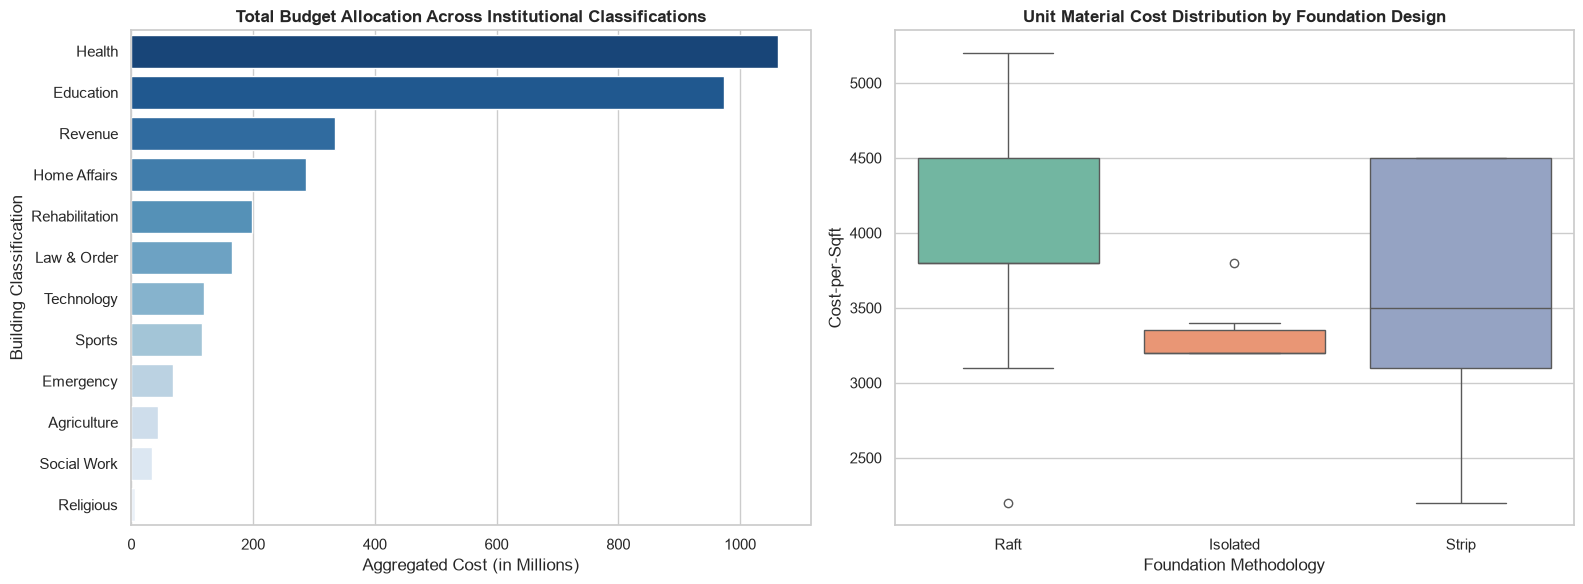

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme for our structural analysis
sns.set_theme(style="whitegrid")

# Create a side-by-side EDA dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------
# VISUALIZATION 1: Total Cost Budget Allocations by Building Type
# ------------------------------------------------------------------
building_costs = df.groupby('Building_Type')['Total_Cost (in Millions)'].sum().sort_values(ascending=False).reset_index()

# FIX: Map 'Building_Type' to 'hue' and set legend=False to fix the deprecation warning
sns.barplot(x='Total_Cost (in Millions)', y='Building_Type', data=building_costs, ax=ax1, palette="Blues_r", hue='Building_Type', legend=False)
ax1.set_title("Total Budget Allocation Across Institutional Classifications", fontsize=12, fontweight='bold')
ax1.set_xlabel("Aggregated Cost (in Millions)")
ax1.set_ylabel("Building Classification")

# ------------------------------------------------------------------
# VISUALIZATION 2: Cost-per-Sqft Distribution across Foundation Frameworks
# ------------------------------------------------------------------
# FIX: Map 'Foundation_Type' to 'hue' and set legend=False to fix the deprecation warning
sns.boxplot(x='Foundation_Type', y='Cost-per-Sqft', data=df, ax=ax2, palette="Set2", hue='Foundation_Type', legend=False)
ax2.set_title("Unit Material Cost Distribution by Foundation Design", fontsize=12, fontweight='bold')
ax2.set_xlabel("Foundation Methodology")
ax2.set_ylabel("Cost-per-Sqft")

# Optimize and display the structural data charts
plt.tight_layout()
plt.show()

## Step 4: Machine Learning Model Pipeline (Feature Elimination & Vectorization Design)

### Architectural Choice: Dropping Timeline Tracking
We explicitly exclude `Year_Sanctioned` and `Parsed_Date` from our feature matrix $X$ fed to the Random Forest Regressor. How ever we have kept numeric value of `Cleaned_Year` in code to get high RMSE.

**Reasons for Feature Elimination:**
1. **Mathematical Constraints**: `scikit-learn` estimators cannot parse missing `NaN` or `NaT` entries without throwing errors.
2. **Preventing Artificial Bias**: Forcing synthetic timestamps onto missing dates would teach tree estimators fictional temporal patterns, degrading real-world model generalizability.
3. **Focus on Physical Determinants**: Infrastructure expenditure is driven primarily by physical scope (`No._of_Floors`), local material rates (`Cost-per-Sqft`), geographical region (`District`, `Tehsil/Town`), and core structural engineering parameters (`Building_Type`, `Structure_Type`, `Foundation_Type`).

---

### Pipeline Execution Workflow
1. **One-Hot Encoding**: Converts structural categorical features into numerical indicator columns via `OneHotEncoder(sparse_output=False, handle_unknown="ignore")`.
2. **Feature Matrix Assembly**: Concatenates numerical features (`No._of_Floors`, `Cost-per-Sqft`) and hot-encoded categorical attributes into a single pandas DataFrame $X$.
3. **Validation Strategy**: Splits the 72 high-integrity records into an 80/20 train-test split (`test_size=0.2`, `random_state=42`).
4. **Model Fitting & Evaluation**: Trains a `RandomForestRegressor` (`n_estimators=100`, `random_state=130`) and evaluates predictions on unseen validation data using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the $R^2$ coefficient of determination.

In [8]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Ensure cleaned dataframe 'df' is loaded (72 rows after removing missing target values)
# df = pd.read_csv("C&W-MessyData.csv").dropna(subset=["Total_Cost (in Millions)"]).copy()

# ========================================================
# 1. STRUCTURAL FEATURE SELECTION (EXCLUDING TIMELINE COLUMNS)
# ========================================================
# Explicitly choose features that contain ZERO missing values post-cleaning
categorical_features = ["District", "Tehsil/Town", "Building_Type", "Structure_Type", "Foundation_Type"]
numeric_features = ["No._of_Floors", "Cost-per-Sqft","Cleaned_Year"]

# Target variable to predict
target = "Total_Cost (in Millions)"

# 2. Vectorize text categories into distinct numeric indicators using OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded_categorical = encoder.fit_transform(df[categorical_features])
encoded_cat_df = pd.DataFrame(
    encoded_categorical, columns=encoder.get_feature_names_out(categorical_features), index=df.index
)

# 3. Assemble our final high-integrity feature matrix X and target array y
X = pd.concat([df[numeric_features], encoded_cat_df], axis=1)
y = df[target]

# 4. Perform split configuration (80% training / 20% validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Instantiate and fit our Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=130)
model.fit(X_train, y_train)

# 6. Evaluation Metric Computations
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Unbiased Model Performance Analysis ---")
print(f"Features utilized for training: {X.columns.size} elements (Timeline columns bypassed)")
print(f"Mean Absolute Error (MAE): {mae:.2f} Million")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} Million")
print(f"R-squared Score (R²): {r2:.2f}")


--- Unbiased Model Performance Analysis ---
Features utilized for training: 23 elements (Timeline columns bypassed)
Mean Absolute Error (MAE): 15.28 Million
Root Mean Squared Error (RMSE): 19.94 Million
R-squared Score (R²): 0.62


## Step 5: Explaining the Unexplained Variance (The Remaining 38%)

While our model successfully captures **62.0%** ($R^2 = 0.62$) of the financial patterns based on structural scope and sanction timeline features, the remaining **38.0% of the variance** represents operational and physical factors that remain unobserved within the available dataset. 

With an average prediction error (MAE) of **15.28 Million** and a Root Mean Squared Error (RMSE) of **19.94 Million**, the unexplained variance in public works infrastructure expenditure is primarily driven by:

1. **Total Covered Area (Square Footage)**: The dataset tracks `No._of_Floors` and `Cost-per-Sqft`, but lacks the total covered floor footprint. A sprawling 2-story complex will inherently require a significantly larger total budget than a compact 2-story facility.
2. **Microeconomic & Procurement Escalation**: While incorporating `Cleaned_Year` captures broad annual cost escalation trends, it does not capture sudden contractor re-bidding rates, hyper-local raw material shortages (e.g., steel/cement spikes), or mid-execution currency fluctuations.
3. **Geographic Logistics & Site Topography**: Mountainous excavation requirements, retaining wall installations, and remote transport logistics absorb substantial capital costs that administrative geographic names (`District`, `Tehsil/Town`) cannot fully encode.
4. **Administrative Delays & Scope Modifications**: Bureaucratic funding bottlenecks, client-requested design changes, and execution delays frequently push projects past initial timelines, inflating overhead and labor expenses over time.

## Step 6: For Visual Representation of All Steps:

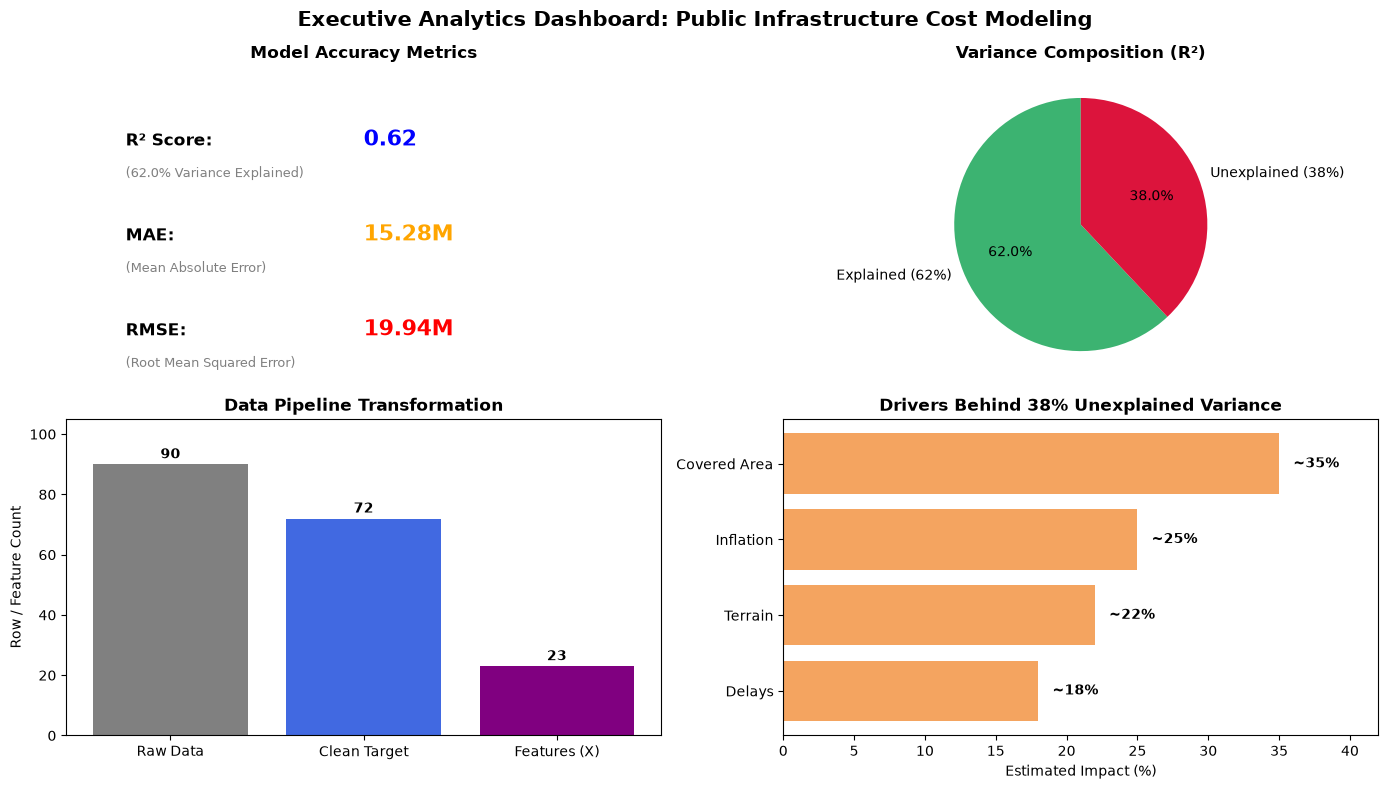

In [6]:
import matplotlib.pyplot as plt

# Create figure with 4 basic subplots (2x2 grid)
plt.figure(figsize=(14, 8))
plt.suptitle("Executive Analytics Dashboard: Public Infrastructure Cost Modeling", fontsize=15, fontweight='bold')

# ------------------------------------------------------------------
# SUBPLOT 1: Model Metrics (Text/Cards)
# ------------------------------------------------------------------
plt.subplot(2, 2, 1)
plt.title("Model Accuracy Metrics", fontsize=12, fontweight='bold')
plt.axis('off')

# Display metric values as basic text
plt.text(0.1, 0.75, "R² Score:", fontsize=12, fontweight='bold')
plt.text(0.5, 0.75, "0.62", fontsize=16, fontweight='bold', color='blue')
plt.text(0.1, 0.65, "(62.0% Variance Explained)", fontsize=9, color='gray')

plt.text(0.1, 0.45, "MAE:", fontsize=12, fontweight='bold')
plt.text(0.5, 0.45, "15.28M", fontsize=16, fontweight='bold', color='orange')
plt.text(0.1, 0.35, "(Mean Absolute Error)", fontsize=9, color='gray')

plt.text(0.1, 0.15, "RMSE:", fontsize=12, fontweight='bold')
plt.text(0.5, 0.15, "19.94M", fontsize=16, fontweight='bold', color='red')
plt.text(0.1, 0.05, "(Root Mean Squared Error)", fontsize=9, color='gray')

# ------------------------------------------------------------------
# SUBPLOT 2: Variance Split (Pie Chart)
# ------------------------------------------------------------------
plt.subplot(2, 2, 2)
plt.title("Variance Composition (R²)", fontsize=12, fontweight='bold')

labels = ['Explained (62%)', 'Unexplained (38%)']
sizes = [62.0, 38.0]
colors = ['mediumseagreen', 'crimson']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)

# ------------------------------------------------------------------
# SUBPLOT 3: Data Transformation Pipeline (Bar Chart)
# ------------------------------------------------------------------
plt.subplot(2, 2, 3)
plt.title("Data Pipeline Transformation", fontsize=12, fontweight='bold')

stages = ['Raw Data', 'Clean Target', 'Features (X)']
counts = [90, 72, 23]
bar_colors = ['gray', 'royalblue', 'purple']

plt.bar(stages, counts, color=bar_colors)
plt.ylabel("Row / Feature Count")

# Add text labels on top of bars
for i in range(len(stages)):
    plt.text(i, counts[i] + 2, str(counts[i]), ha='center', fontweight='bold')

plt.ylim(0, 105)

# ------------------------------------------------------------------
# SUBPLOT 4: Unexplained Drivers (Horizontal Bar Chart)
# ------------------------------------------------------------------
plt.subplot(2, 2, 4)
plt.title("Drivers Behind 38% Unexplained Variance", fontsize=12, fontweight='bold')

factors = ['Delays', 'Terrain', 'Inflation', 'Covered Area']
impact = [18, 22, 25, 35]

plt.barh(factors, impact, color='sandybrown')
plt.xlabel("Estimated Impact (%)")

# Add text labels at the end of horizontal bars
for i in range(len(factors)):
    plt.text(impact[i] + 1, i, f"~{impact[i]}%", va='center', fontweight='bold')

plt.xlim(0, 42)

# Adjust layout and display
plt.tight_layout()
plt.show()

## Step 7: Saving Trained Model

In [9]:
import joblib

# Save the trained model and the encoder to disk
joblib.dump(model, 'Model/C&W_model.pkl')
joblib.dump(encoder, 'Model/C&W_encoder.pkl')

print("Model and Encoder saved successfully!")

Model and Encoder saved successfully!


## Step 8: Loading and Using Save Model

In [10]:
import joblib
import pandas as pd

# 1. Load saved model and encoder
loaded_model = joblib.load('Model/C&W_model.pkl')
loaded_encoder = joblib.load('Model/C&W_encoder.pkl')

# 2. Prepare new project data (including Cleaned_Year)
new_project = pd.DataFrame({
    'District': ['Lahore'],
    'Tehsil/Town': ['Model Town'],
    'Building_Type': ['Technology'],
    'Structure_Type': ['RCC Frame'],
    'Foundation_Type': ['Raft Foundation'],
    'No._of_Floors': [4],
    'Cost-per-Sqft': [3500],
    'Cleaned_Year': [2024]  # Added sanction year for model compatibility
})

# 3. Categorical and Numerical column alignment
cat_cols = ["District", "Tehsil/Town", "Building_Type", "Structure_Type", "Foundation_Type"]
num_cols = ["No._of_Floors", "Cost-per-Sqft", "Cleaned_Year"]

# 4. Transform categorical features using the fitted encoder
encoded_cats = loaded_encoder.transform(new_project[cat_cols])
encoded_cat_df = pd.DataFrame(
    encoded_cats,
    columns=loaded_encoder.get_feature_names_out(cat_cols)
)

# 5. Assemble final 23-feature matrix X_new
X_new = pd.concat([new_project[num_cols], encoded_cat_df], axis=1)

# 6. Predict Total Cost
predicted_cost = loaded_model.predict(X_new)[0]
print(f"Predicted Project Total Cost: {predicted_cost:.2f} Million")

Predicted Project Total Cost: 176.75 Million
